### Bernoulli Processes

Bernoulli Process is a sequence of independent Bernoulli trials. For each trial $i$, $P(X_i=1) = p$ and $P(X_i=0) = 1-p$. Assumptions we make are independence and time-homogeneity.

Stochastic Processes Views
1.Sequence of Random Variables ($X_1, ..., X_n$). Per trial $X_i$: $E[X_i] = p$, $Var(X_i) = p(1-p)$. PMF for $X_i$, $P_{X_i}(x) = \begin{cases} p & \text{if } x=1 \\ 1-p & \text{if } x=0 \end{cases}$. Joint PMF (independent trials): $P_{X_1,...,X_n}(x_1,...,x_n) = \prod_{k=1}^n P_{X_k}(x_k)$.

Sample Space $\Omega = \{\text{infinite sequences of 0's and 1's}\}$

**Number of Successes / Arrivals ($S$ in $n$ time slots)**

Let $S = X_1 + ... + X_n$ be the total number of successes in $n$ trials. PMF for $S$: $P(S=k) = \binom{n}{k} p^k (1-p)^{n-k}$ for $k = 0, 1, 2, ..., n$. Expectation: $E[S] = n \cdot p$. Variance: $Var(S) = n \cdot p (1-p)$.

#### Time until the First Success/Arrival
Let $T_1 = \min\{i: X_i = 1\}$ be the time of the first success. PMF for $T_1$ (Geometric Distribution) $P(T_1 = k) = P(\{0,0,...,0,1\}) = (1-p)^{k-1} p$ for $k = 1, 2, 3, ...$. Expectation $E[T_1] = \frac{1}{p}$. Variance $Var(T_1) = \frac{1-p}{p^2}$.

#### Derivation of the Memoryless Property for the Geometric Distribution

The Geometric distribution describes the number of Bernoulli trials needed to get the first success. Let $T$ be a Geometric random variable with parameter $p$, so $P(T=k) = (1-p)^{k-1}p$ for $k=1, 2, 3, \dots$. The **memoryless property** states that for any non-negative integers $t$ and $s$, the probability that the next success is still $s$ trials away, given that no success has occurred in the first $t$ trials, is the same as the original probability that the first success is $s$ trials away. Mathematically $P(T > t+s \mid T > t) = P(T > s)$

Let's derive this property:

First, we need the probability that $T > k$, which means that the first $k$ trials were all failures:
$P(T > k) = \sum_{j=k+1}^{\infty} P(T=j) = \sum_{j=k+1}^{\infty} (1-p)^{j-1}p$. This is the sum of a geometric series starting from $k+1$. Alternatively, $P(T > k)$ is simply the probability of $k$ consecutive failures:
$P(T > k) = (1-p)^k$. Now, let's look at the conditional probability $P(T > t+s \mid T > t)$: $P(T > t+s \mid T > t) = \frac{P(T > t+s \text{ and } T > t)}{P(T > t)}$. Since the event $(T > t+s)$ implies $(T > t)$, the intersection of these two events is simply $(T > t+s)$.

The expression becomes: $P(T > t+s \mid T > t) = \frac{P(T > t+s)}{P(T > t)}$. Substitute the formula for $P(T > k)$: $P(T > t+s \mid T > t) = \frac{(1-p)^{t+s}}{(1-p)^t}$. Using exponent rules, we can simplify this: $P(T > t+s \mid T > t) = (1-p)^{(t+s) - t} = (1-p)^s$. And we know that $P(T > s) = (1-p)^s$. Therefore, we have demonstrated the memoryless property
- $P(T > t+s \mid T > t) = P(T > s)$

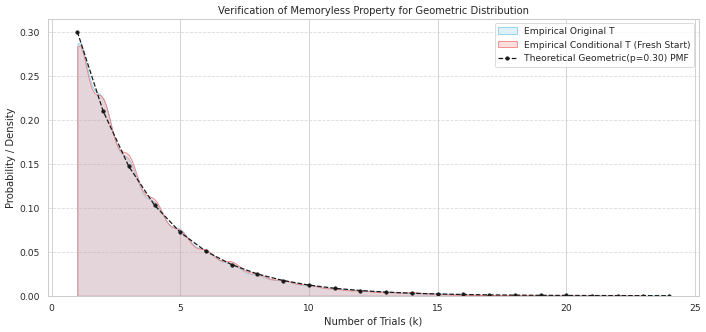

--- Statistics for Original Geometric (p=0.30) ---
Sample Mean: 3.32 (Theoretical: 3.33)
Sample Variance: 7.74 (Theoretical: 7.78)

--- Statistics for Conditional Geometric (p=0.30) ---
Sample Mean: 3.33 (Theoretical: 3.33)
Sample Variance: 7.53 (Theoretical: 7.78)


In [ ]:
''' Verification of Memoryless Property for Geometric Distribution '''

#### Time until the First Failure

Let $U = \min\{n: X_n = 0\}$ be the time when a value of 0 is first observed in a Bernoulli process with parameter $P(X_n=1) = p$. This means the probability of observing a 'failure' (a 0) in any given trial is $P(X_n=0) = 1 - p$.

The random variable $U$ follows a **Geometric distribution with parameter $(1-p)$**.

This is because the Geometric distribution models the number of independent Bernoulli trials required to get the first 'success'. In this context, observing a 0 is considered the 'success' we are waiting for. The probability of this 'success' on any single trial is $1-p$.

The PMF for $U$ is: $P(U = k) = (1 - p) \cdot p^{k-1}$ for $k = 1, 2, 3, ...$

*   Expectation: $E[U] = \frac{1}{1-p}$, Variance: $Var(U) = \frac{p}{(1-p)^2}$

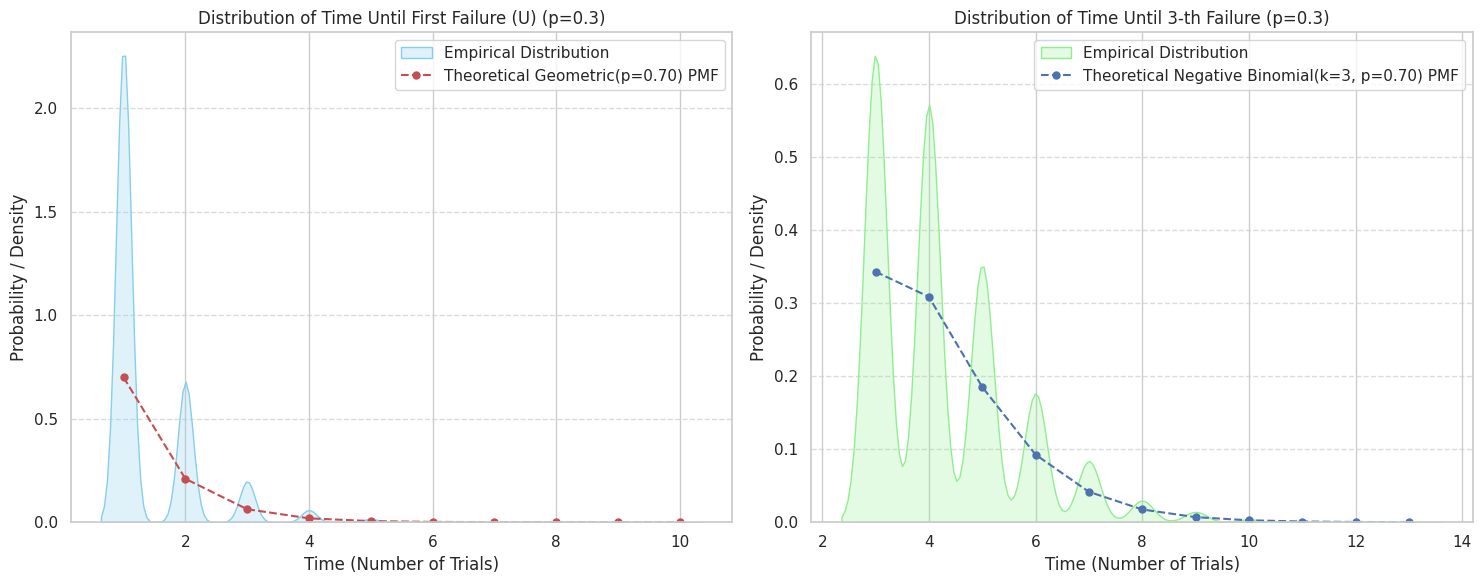

--- Statistics for 1-st Failure (Geometric) ---
Sample Mean of U1: 1.42 (Theoretical: 1.43)
Sample Variance of U1: 0.60 (Theoretical: 0.61)

--- Statistics for 3-th Failure (Negative Binomial) ---
Sample Mean of Uk: 4.29 (Theoretical: 4.29)
Sample Variance of Uk: 1.80 (Theoretical: 1.84)


In [ ]:
# Define a probability for success (of Xn=1)
p = 0.3
# Probability of 'failure' (Xn=0), which is the parameter for the Geometric distribution of U
# This is also the success probability for Negative Binomial when counting failures
param_geometric_U = 1 - p

def simulate_kth_failure_time(p_success, k_target_failures, num_simulations=10000):
    kth_failure_times = []
    for _ in range(num_simulations):
        failures_count = 0
        trials = 0
        while failures_count < k_target_failures:
            trials += 1
            # Simulate Bernoulli trial: 1 with prob p_success, 0 with prob 1-p_success
            if np.random.rand() >= p_success: # If outcome is 0 (failure in process)
                failures_count += 1
        kth_failure_times.append(trials)
    return np.array(kth_failure_times)

# first failure (k=1)
k_first_failure = 1
first_failure_data = simulate_kth_failure_time(p, k_first_failure)

# k-th failure
k_failures_to_simulate = 3 # Let's pick k=3 for demonstration
kth_failure_data = simulate_kth_failure_time(p, k_failures_to_simulate)

# Subplot 1: Time until First Failure (k=1)
x_vals_first_failure_theory = np.arange(1, np.max(first_failure_data) + 1)
theoretical_pmf_first_failure = geom.pmf(x_vals_first_failure_theory, p=param_geometric_U) # Geometric(1-p) is equivalent to Negative Binomial(1, 1-p)

# Subplot 2: Time until K-th Failure (k=k_failures_to_simulate)
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
x_vals_kth_failure_theory = np.arange(k_failures_to_simulate, np.max(kth_failure_data) + 1)
# Negative Binomial PMF: nbinom.pmf(k_observed_failures, n_target_failures, prob_of_success_for_target) - 'success' is a failure (0) in the Bernoulli process, so prob is param_geometric_U (1-p)
theoretical_pmf_kth_failure = nbinom.pmf(x_vals_kth_failure_theory - k_failures_to_simulate, k_failures_to_simulate, param_geometric_U)

# sample and theoretical statistics for both
sample_mean_U1 = np.mean(first_failure_data)
sample_var_U1 = np.var(first_failure_data)
theoretical_mean_U1 = 1 / param_geometric_U
theoretical_var_U1 = p / (param_geometric_U**2)

print(f"Statistics for {k_failures_to_simulate}-th Failure (Negative Binomial)")
sample_mean_Uk = np.mean(kth_failure_data)
sample_var_Uk = np.var(kth_failure_data)
theoretical_mean_Uk = k_failures_to_simulate / param_geometric_U
theoretical_var_Uk = k_failures_to_simulate * p / (param_geometric_U**2) # Var = k * (1-q)/q^2 = k * p / (1-p)^2

#### Independence, Memorylessness, and Fresh-Start Properties

For a sequence of independent Bernoulli trials $\{X_i\} \sim \text{Ber}(p)$:

**Independence**: Each trial's outcome is independent of all past and future outcomes.

**Memorylessness (for Waiting Times)**: The probability that an event occurs in the future does not depend on how long it has not occurred in the past.
For e.g., if we are waiting for the first success, and it hasn't happened by trial $n$, the probability distribution of the *additional* waiting time is the same as the original waiting time distribution.

**Fresh-Start Property**: If we stop observing the process at any point $n$, and restart observing from $X_{n+1}$, the sequence $Y_j = X_{n+j}$ for $j=1, 2, ...$ constitutes a new Bernoulli process with the same parameter $p$, independent of $X_1, ..., X_n$.
For e.g. If $Y_1 = X_6$ and $Y_2 = X_7$, then $\{Y_i\}$ is independent of $X_1, ..., X_5$ and also follows a $\text{Ber}(p)$ process.
More generally, if $N$ is a stopping time (a random variable representing the time at which we stop observing the process), then $X_{N+1}, X_{N+2}, \dots$ is a Bernoulli process independent of $N, X_1, \dots, X_N$. For instance, if $T_1 = \min\{i: X_i = 1\}$ is the time of the first success, then $Y_1 = X_{T_1+1}, Y_2 = X_{T_1+2}, \dots$ is a Bernoulli process independent of $X_1, \dots, X_{T_1}$.

#### Conditional Expectation of the Second Interarrival Time in a Bernoulli Process

Consider a Bernoulli process with parameter $p$. Let $T_1$ be the time of the first success and $T_2$ be the second interarrival time. $T_2$ represents the number of additional trials required to observe the second success, starting from trial $T_1+1$. It follows an independent Geometric distribution with parameter $p$, so $E[T_2] = 1/p$.

Assume that the results of the two slots that follow the first success are failures, i.e., $X_{T_1+1} = 0$ and $X_{T_1+2} = 0$.

We want to express the conditional expectation of the second interarrival time $T_2$ given this information: $E[T_2 \mid X_{T_1+1} = 0, X_{T_1+2} = 0]$.

1.  **Interarrival Times ($T_k$) are i.i.d. Geometric:** In a Bernoulli process, each interarrival time $T_k$ (the number of trials between the $(k-1)$-th and $k$-th success) follows an independent and identically distributed Geometric distribution with parameter $p$. The expected value of a Geometric random variable with parameter $p$ is $E[T_k] = 1/p$.

2.  **Fresh-Start Property of Bernoulli Process:** After the first success occurs at time $T_1$, the process effectively "resets" and restarts from trial $T_1+1$. The sequence of trials $X_{T_1+1}, X_{T_1+2}, \dots$ constitutes a new, independent Bernoulli process with the same parameter $p$.

3.  **Memoryless Property of Geometric Distribution (for expected values):** The random variable $T_2$ represents the waiting time for the next success from trial $T_1+1$ onwards. The information that $X_{T_1+1} = 0$ and $X_{T_1+2} = 0$ tells us that the second success did *not* occur in the first two trials immediately following $T_1$. This means we know $T_2 > 2$.

    For a Geometric random variable $T$, the memoryless property implies that $E[T \mid T > t] = t + E[T]$.

    Applying this property:
    $E[T_2 \mid X_{T_1+1} = 0, X_{T_1+2} = 0] = E[T_2 \mid T_2 > 2]$.

    Therefore, the conditional expectation of $T_2$ is:
    $E[T_2 \mid T_2 > 2] = 2 + E[T_2]$.

    Since $E[T_2] = \frac{1}{p}$, we have:
    - $E[T_2 \mid X_{T_1+1} = 0, X_{T_1+2} = 0] = 2 + \frac{1}{p}$

This shows that if we observe two failures, the expected total waiting time for the next success increases by the number of observed failures, even though the *remaining* waiting time (from the point of last observation) retains the original Geometric distribution.

#### Fresh-Start Property at Specific Random Times in Bernoulli Processes

For a Bernoulli process, the 'fresh-start property' means that at any point in time, the future behavior of the process is independent of its past, given the current state. This property is particularly profound when considering *random stopping times*.

More formally, if $N$ is a stopping time (a random variable whose value is determined by the outcomes of the process up to that time), then the process *after* $N$ is statistically identical to the original Bernoulli process, independent of the past outcomes up to $N$.

Let $X_1, X_2, \dots$ be an i.i.d. Bernoulli($p$) sequence.

1.  **Fresh Start After the $k$-th Failure**: If we define $N_k$ as the trial number where the $k$-th failure (outcome '0') occurs, then the sequence of trials $X_{N_k+1}, X_{N_k+2}, \dots$ is an independent Bernoulli process with the same parameter $p$, completely uninfluenced by the $k$ failures and previous successes.

2.  **Fresh Start After a Failure Follows a Success (pattern '10')**: Consider the first time we observe a '1' immediately followed by a '0'. Let $N_{10}$ be the trial number of this '0'. The sequence $X_{N_{10}+1}, X_{N_{10}+2}, \dots$ is again an independent Bernoulli process. The occurrence of the '10' pattern does not provide any 'memory' to bias subsequent outcomes.

3.  **Fresh Start After a '01' Pattern**: Similarly, if we define $N_{01}$ as the trial number of the '1' in the first observed '01' pattern (i.e., $X_{N_{01}-1}=0$ and $X_{N_{01}}=1$), the process $X_{N_{01}+1}, X_{N_{01}+2}, \dots$ is a fresh Bernoulli process. The future trials are independent of the fact that the previous two trials formed a '01' sequence.

These examples highlight that for a Bernoulli process, the process effectively 'resets' its memory at any random point determined by the process's own history, as long as that point doesn't look into the future.

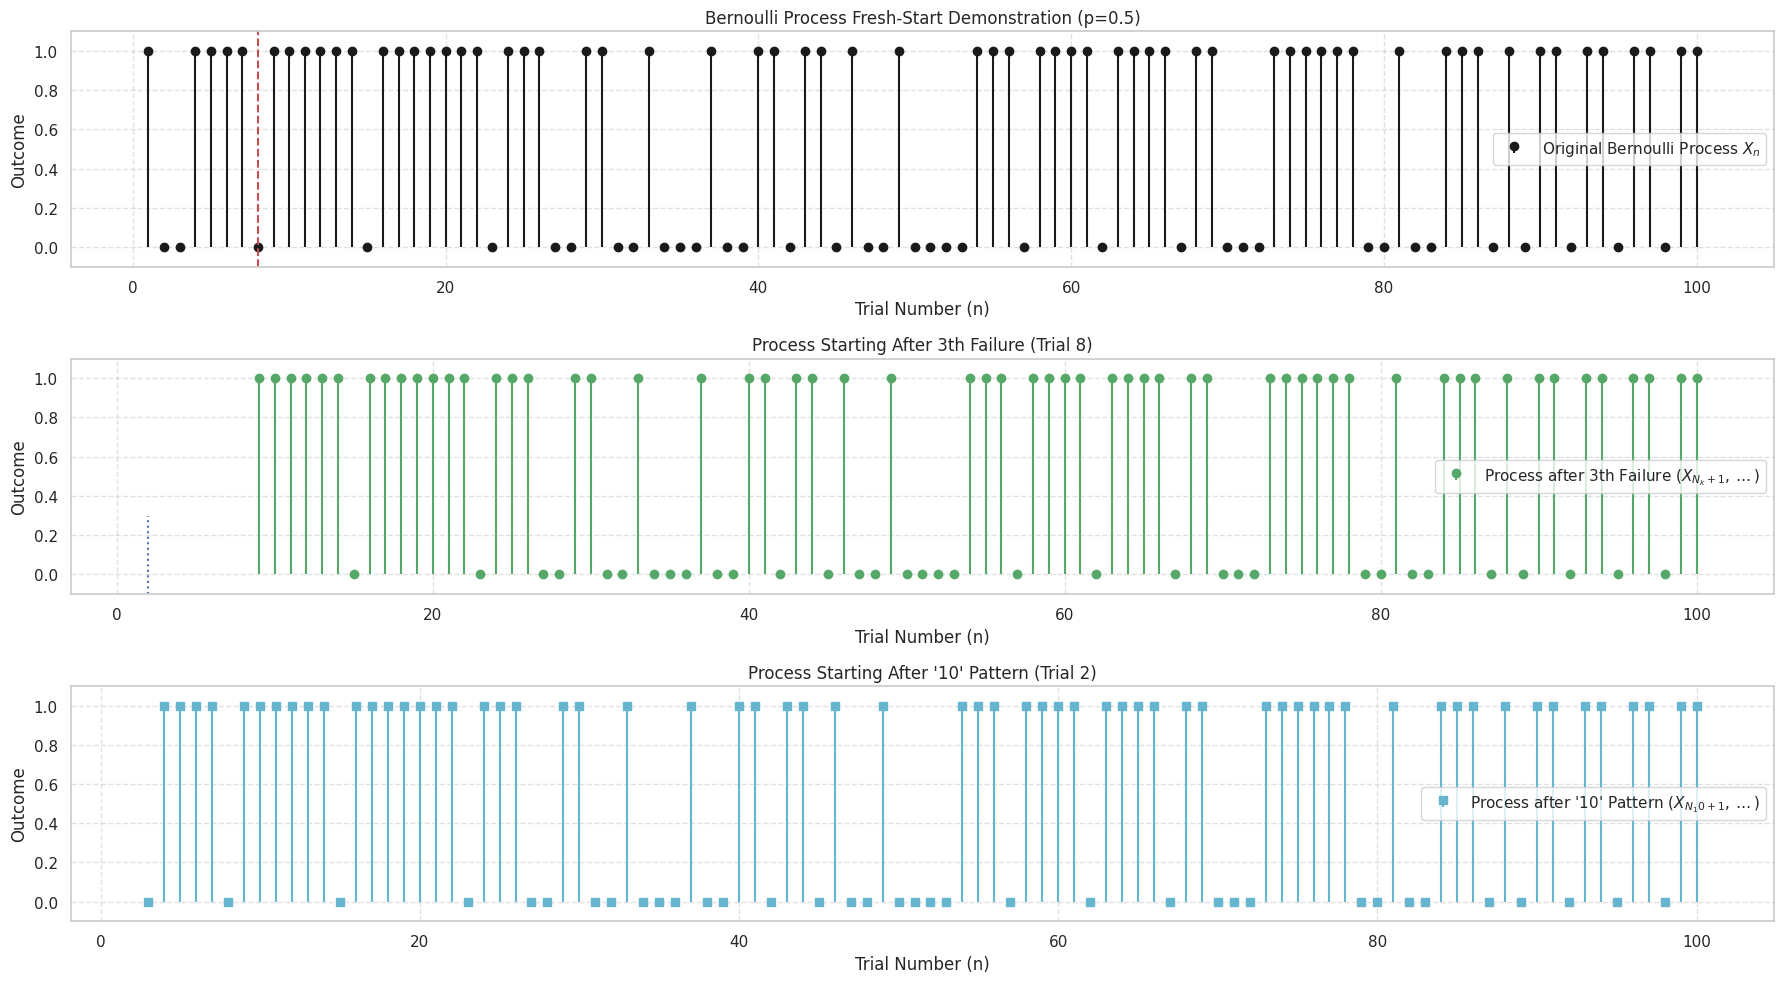

In [ ]:
def simulate_bernoulli_process(p, num_trials):
    return (np.random.rand(num_trials) < p).astype(int)

def find_kth_failure_time(process, k):
    failures_found = 0
    for i, outcome in enumerate(process):
        if outcome == 0:
            failures_found += 1
        if failures_found == k:
            return i + 1 # 1-based index of the k-th failure
    return -1 # Not found

def find_pattern_time(process, pattern):
    # pattern is a tuple, e.g., (1, 0) for '10'
    for i in range(len(process) - len(pattern) + 1):
        match = True
        for j in range(len(pattern)):
            if process[i+j] != pattern[j]:
                match = False
                break
        if match:
            return i + len(pattern) # 1-based index of the last element in the pattern
    return -1 # Not found

# Define Bernoulli probability
p_fresh = 0.5
num_sim_trials = 100 # Total trials for one simulation run

# Simulate a long Bernoulli process
full_process = simulate_bernoulli_process(p_fresh, num_sim_trials)

# Scenario 1: Fresh start after k-th failure
k_target = 3
kth_failure_idx = find_kth_failure_time(full_process, k_target)

# Scenario 2: Fresh start after '10' pattern
pattern_10_idx = find_pattern_time(full_process, (1, 0))

# Scenario 3: Fresh start after '01' pattern
pattern_01_idx = find_pattern_time(full_process, (0, 1))

# Highlight k-th failure fresh start

# Highlight '10' pattern fresh start
# Note: Due to space constraints and to clearly demonstrate the 'fresh start' concept, the visualization focuses on two specific random times at once to avoid overly complex plots.
# Running the cell multiple times will show different starting points due to random simulation.

#### Distribution of Busy Periods

In a Bernoulli process, if we consider 'success' as a slot being busy and 'failure' as a slot being idle, then busy periods naturally arise. A busy period is defined as a sequence of consecutive busy slots, starting with a busy slot and ending just before the first idle slot.

Due to the **Fresh-Start Property** of a Bernoulli process, any busy period (first, second, or subsequent) is an independent and identically distributed random variable.

If the probability of a slot being busy is $p$:
- The **length of any busy period** (i.e., the number of consecutive busy slots before an idle slot) follows a **Geometric distribution** with parameter $(1-p)$. This is because we are essentially waiting for the first 'failure' (an idle slot), which has probability $1-p$.
  - The PMF for a busy period of length $k$ is $P(\text{length}=k) = (1-p)p^{k-1}$ for $k=1, 2, 3, \dots$.
  - Expectation: $E[\text{length}] = \frac{1}{1-p}$
  - Variance: $Var[\text{length}] = \frac{p}{(1-p)^2}

#### Merging Independent Bernoulli Processes

We start with two independent Bernoulli processes, $X_n$ and $Y_n$, with parameters $p$ and $q$, respectively. We form a new process $Z_n$ by recording an arrival in a given time slot if and only if both of the original processes record an arrival in that same time slot. Mathematically, $Z_n = X_n Y_n$.

In this case, the new process $Z_n$ is also a Bernoulli process. The probability of success for $Z_n$ is $P(Z_n=1) = P(X_n=1, Y_n=1)$. Since $X_n$ and $Y_n$ are independent, $P(Z_n=1) = P(X_n=1)P(Y_n=1) = pq$. Thus, $Z_n ~ Bernoulli(pq)$.



#### Variation on Merging Dependent Bernoulli Processes

Suppose that the two Bernoulli processes $X_n$ and $Y_n$ are dependent. We still assume, however, that the pairs $(X_n, Y_n)$ are independent for different time slots (i.e., $(X_1, Y_1)$ is independent from $(X_2, Y_2)$, etc.). In this scenario, the process $Z_n = X_n Y_n$ isn't guaranteed to be a Bernoulli process. While each individual $Z_n$ will still be a Bernoulli random variable (it can only take values 0 or 1), the *sequence* $Z_n$ might not satisfy the independence and time-homogeneity properties required for a Bernoulli process, as the dependency structure between $X_n$ and $Y_n$ could introduce complex dependencies in $Z_n$ over time, or the probability $P(Z_n=1)$ could vary if the dependency changes.

#### Plot: Time until the First Success ($T_1$ - Geometric Distribution)

We simulate a Bernoulli process many times and record the trial number when the first success occurs. The distribution of these trial numbers should follow a Geometric distribution with parameter $p$.

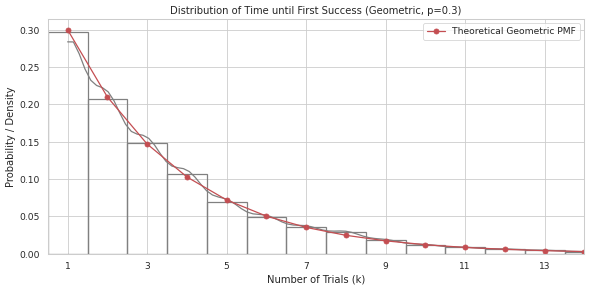

Sample Mean of T1: 3.35 (Theoretical: 3.33)
Sample Variance of T1: 7.70 (Theoretical: 7.78)


In [ ]:
# Define a probability for success
p = 0.3

def simulate_first_success_time(p, num_simulations=10000):
    first_success_times = []
    for _ in range(num_simulations):
        trials = 0
        while True:
            trials += 1
            if np.random.rand() < p:
                first_success_times.append(trials)
                break
    return np.array(first_success_times)

# Simulate times until first success
first_success_data = simulate_first_success_time(p)

# Overlay theoretical PMF
x_vals = np.arange(1, np.max(first_success_data) + 1)
theoretical_pmf = (1 - p)**(x_vals - 1) * p

#### Plot: Inter-arrival Times ($T_k$ - i.i.d. Geometric Distribution)

The inter-arrival times (time between consecutive successes) are also independent and identically distributed Geometric random variables. This demonstrates the 'fresh-start' property after each success.

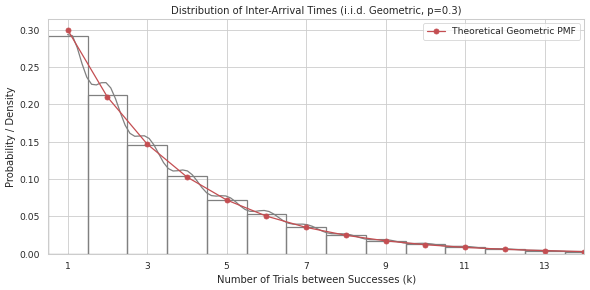

Sample Mean of Inter-arrival times: 3.38 (Theoretical: 3.33)
Sample Variance of Inter-arrival times: 7.93 (Theoretical: 7.78)


In [ ]:
def simulate_inter_arrival_times(p, total_trials=10000):
    inter_arrival_times = []
    last_success_time = 0
    for i in range(1, total_trials + 1):
        if np.random.rand() < p:
            inter_arrival_times.append(i - last_success_time)
            last_success_time = i
    return np.array(inter_arrival_times)

inter_arrival_data = simulate_inter_arrival_times(p, total_trials=50000) # More trials for more inter-arrivals

# Overlay theoretical PMF (should be the same Geometric as T1)
x_vals_inter = np.arange(1, np.max(inter_arrival_data) + 1)
theoretical_pmf_inter = (1 - p)**(x_vals_inter - 1) * p

#### Plot: Time of the k-th Success ($Y_k$ - Negative Binomial Distribution)

$Y_k$ is the total time (number of trials) until the $k$-th success. This is the sum of $k$ independent Geometric random variables, leading to a Negative Binomial distribution.

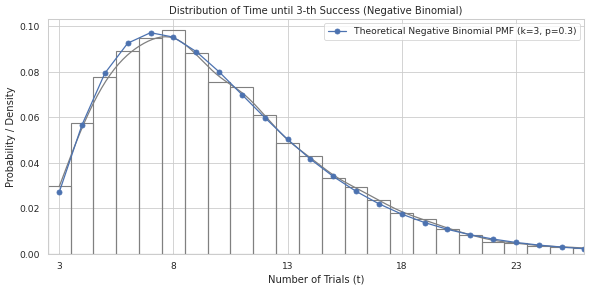

Sample Mean of Y3: 10.00 (Theoretical: 10.00)
Sample Variance of Y3: 22.92 (Theoretical: 23.33)


In [ ]:
def simulate_kth_success_time(p, k, num_simulations=10000):
    kth_success_times = []
    for _ in range(num_simulations):
        success_count = 0
        trials = 0
        while success_count < k:
            trials += 1
            if np.random.rand() < p:
                success_count += 1
        kth_success_times.append(trials)
    return np.array(kth_success_times)

# Let's simulate for k=3 successes
k_successes = 3
kth_success_data = simulate_kth_success_time(p, k_successes)

# Overlay theoretical PMF for Negative Binomial (using scipy)
x_vals_kth = np.arange(k_successes, np.max(kth_success_data) + 1)
theoretical_pmf_kth = nbinom.pmf(x_vals_kth - k_successes, k_successes, p)

#### Plot: Distribution of Busy Periods

For a server where 'success' means busy, a busy period starts with the first busy slot and ends just before the first subsequent idle slot. The length of this busy period follows a Geometric distribution with parameter $(1-p)$ (the probability of an idle slot).

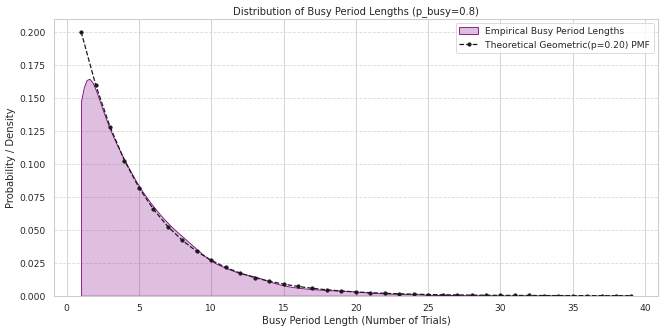

Sample Mean of Busy Period Lengths: 4.97 (Theoretical for Geo(p_idle): 5.00)
Sample Variance of Busy Period Lengths: 19.34 (Theoretical for Geo(p_idle): 20.00)


In [ ]:
def simulate_busy_period_lengths(p_busy, num_simulations=10000):
    busy_period_lengths = []
    for _ in range(num_simulations):
        # A busy period must start with a busy slot
        if np.random.rand() < p_busy:
            length = 1 # The first busy slot itself
            while True:
                # Check for the next slot. If busy, continue the period.
                if np.random.rand() < p_busy:
                    length += 1
                else:
                    # If idle, the busy period ends here
                    busy_period_lengths.append(length)
                    break
        else:
            # If it starts with an idle slot, we don't count it as the start of a busy period for this simulation
            pass # We only count periods that actually start with busy
    return np.array(busy_period_lengths)

p_busy = 0.8 # Probability that a slot is busy
p_idle = 1 - p_busy # Probability that a slot is idle (parameter for Geometric distribution)

busy_period_data = simulate_busy_period_lengths(p_busy)

# Filter out cases where no busy period was observed (shouldn't happen with the current logic if num_simulations is large enough)
busy_period_data = busy_period_data[busy_period_data > 0]

# Overlay theoretical PMF (Geometric with parameter p_idle)
x_vals_busy = np.arange(1, np.max(busy_period_data) + 1)
# The PMF for Geometric(q) is q * (1-q)**(k-1). Here q = p_idle.
theoretical_pmf_busy = geom.pmf(x_vals_busy, p=p_idle)

#### Plot: Merged Independent Bernoulli Processes

This plot visualizes two independent Bernoulli processes, $X$ and $Y$, with probabilities $p_1$ and $p_2$ respectively, and their merged process $Z$. An 'arrival' in the merged process $Z$ occurs if there is an arrival in *either* process $X$ or process $Y$ at that specific trial.

**Process X** (green triangles) shows arrivals from the first Bernoulli process.
**Process Y** (blue squares) shows arrivals from the second independent Bernoulli process. **Merged Process Z** (red circles) arrivals when at least one of Process X or Process Y has an arrival.

Due to the independence of $X$ and $Y$, the probability of an arrival in the merged process $Z$ is given by $P(Z=1) = P(X=1 \text{ or } Y=1) = P(X=1) + P(Y=1) - P(X=1)P(Y=1) = p_1 + p_2 - p_1 p_2$.

In [ ]:
def simulate_merged_bernoulli(p, q, num_trials=10000):
    merged_arrivals = 0
    first_process_given_merged = 0
    total_merged_events = 0

    for _ in range(num_trials):
        x_t = 1 if random.random() < p else 0
        y_t = 1 if random.random() < q else 0

        z_t = 1 if (x_t == 1 or y_t == 1) else 0

        if z_t == 1:
            merged_arrivals += 1
            if x_t == 1:
                first_process_given_merged += 1

        # Count merged events specifically for the conditional probability denominator
        if z_t == 1:
            total_merged_events += 1

    empirical_p_merged = merged_arrivals / num_trials

    empirical_conditional_p = first_process_given_merged / total_merged_events if total_merged_events > 0 else 0

    return empirical_p_merged, empirical_conditional_p

In [ ]:
# Define custom probabilities for the two independent Bernoulli processes

p_process1 = 0.6  # Custom value for p
p_process2 = 0.2  # Custom value for q

# Simulate the merged process
empirical_p_merged, empirical_conditional_p = simulate_merged_bernoulli(p_process1, p_process2)

# Theoretical probabilities
theoretical_p_merged = p_process1 + p_process2 - (p_process1 * p_process2)
theoretical_conditional_p = p_process1 / theoretical_p_merged

--- Merging Bernoulli Processes (p1=0.6, p2=0.2) ---
Empirical P(Merged Arrival): 0.6790
Theoretical P(Merged Arrival): 0.6800
Difference: 0.0010

Empirical P(Process 1 Arrival | Merged Arrival): 0.8863
Theoretical P(Process 1 Arrival | Merged Arrival): 0.8824
Difference: 0.0040


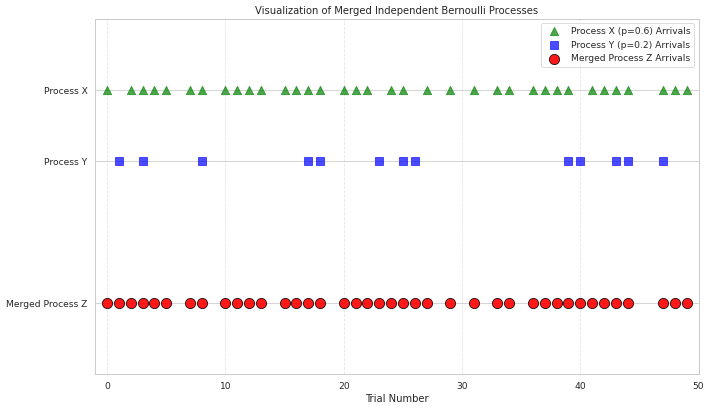

In [ ]:
def simulate_and_plot_merged_processes(p1, p2, num_trials=100):
    # Simulate individual Bernoulli processes
    x_process = (np.random.rand(num_trials) < p1).astype(int)
    y_process = (np.random.rand(num_trials) < p2).astype(int)

    # Simulate the merged process (arrival if either X or Y has an arrival)
    z_process = ((x_process == 1) | (y_process == 1)).astype(int)

    # Get trial indices where arrivals occur
    x_arrivals = np.where(x_process == 1)[0]
    y_arrivals = np.where(y_process == 1)[0]
    z_arrivals = np.where(z_process == 1)[0]

    # Plot individual processes, and merged process

# Reuse the custom probabilities defined earlier
p_process1 = 0.6
p_process2 = 0.2

simulate_and_plot_merged_processes(p_process1, p_process2, num_trials=50)

#### Plot: Splitting of a Bernoulli Process

Consider an original Bernoulli process $X_t$ with success probability $p$. We can split the successes of this process into two new streams, $Y_{1,t}$ and $Y_{2,t}$. This is done by independently flipping a 'splitting coin' with bias $q$ for each success in $X_t$. If the splitting coin lands 'heads' (with probability $q$), the success goes to stream $Y_{1,t}$. If it lands 'tails' (with probability $1-q$), the success goes to stream $Y_{2,t}$.

-   The first stream, $Y_{1,t}$, will have a success probability of $P(Y_1=1) = P(X=1 \text{ and splitting coin is heads}) = P(X=1) \cdot P(\text{splitting coin is heads}) = p \cdot q$.
-   The second stream, $Y_{2,t}$, will have a success probability of $P(Y_2=1) = P(X=1 \text{ and splitting coin is tails}) = P(X=1) \cdot P(\text{splitting coin is tails}) = p \cdot (1-q)$.

Although $Y_1$ and $Y_2$ are derived from independent coin flips *given* a success in $X$, the two streams **$Y_1$ and $Y_2$ are not independent** of each other. This is because both streams depend on the occurrence of a success in the original process $X$. For example, if $X_t = 0$, then both $Y_{1,t}$ and $Y_{2,t}$ must also be $0$.

In [ ]:
def simulate_bernoulli_splitting(p_original, q_split, num_trials=10000):
    original_successes = 0
    stream1_successes = 0
    stream2_successes = 0
    for _ in range(num_trials):
        # Original Bernoulli process
        if random.random() < p_original:
            original_successes += 1
            # Split the success based on q_split
            if random.random() < q_split:
                stream1_successes += 1
            else:
                stream2_successes += 1

    empirical_p_original = original_successes / num_trials
    empirical_p_stream1 = stream1_successes / num_trials
    empirical_p_stream2 = stream2_successes / num_trials
    return empirical_p_original, empirical_p_stream1, empirical_p_stream2

# Define parameters for the original process and splitting coin
p_original = 0.5  # Probability of success for the original Bernoulli process
q_split = 0.4  # Bias of the splitting coin (probability of going to stream 1)

# Simulate the splitting
emp_p_orig, emp_p_s1, emp_p_s2 = simulate_bernoulli_splitting(p_original, q_split)

# Theoretical probabilities
theoretical_p_s1 = p_original * q_split
theoretical_p_s2 = p_original * (1 - q_split)

--- Bernoulli Process Splitting (p_original=0.5, q_split=0.4) ---
Original Process (X): Empirical P(Success) = 0.5011
Stream 1 (Y1): Empirical P(Success) = 0.2010 (Theoretical: 0.2000)
Stream 2 (Y2): Empirical P(Success) = 0.3001 (Theoretical: 0.3000)
Check: P(Y1) + P(Y2) = 0.5011 (Should be close to P(X) = 0.5011)


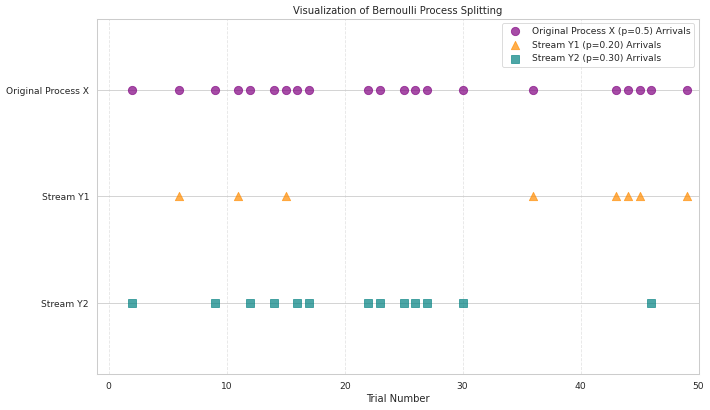

In [ ]:
def plot_bernoulli_splitting(p_original, q_split, num_trials=100):
    x_process = (np.random.rand(num_trials) < p_original).astype(int)
    y1_process = np.zeros(num_trials, dtype=int)
    y2_process = np.zeros(num_trials, dtype=int)

    for i in range(num_trials):
        if x_process[i] == 1:
            if np.random.rand() < q_split:
                y1_process[i] = 1
            else:
                y2_process[i] = 1

    x_arrivals = np.where(x_process == 1)[0]
    y1_arrivals = np.where(y1_process == 1)[0]
    y2_arrivals = np.where(y2_process == 1)[0]

# Reuse the parameters defined earlier
plot_bernoulli_splitting(p_original, q_split, num_trials=50)

#### Explanation of Bernoulli Process Splitting Visualization

This plot illustrates how an original Bernoulli process (Process X, shown in purple circles) is split into two new streams (Stream Y1 in orange triangles and Stream Y2 in teal squares).

**Original Process X** represents the main Bernoulli process with a probability of success p_original. **Stream Y1** shows arrivals that originated from Process X successes and were directed to Stream Y1 by the splitting coin (with bias q_split). Its effective probability of arrival is p_original q_split. **Stream Y2** shows arrivals that originated from Process X successes and were directed to Stream Y2 by the splitting coin (with bias 1 - q_split). Its effective probability of arrival is p_original * (1 - q_split).

Notice that at any given trial, if Process X has no arrival, neither Y1 nor Y2 will have an arrival. If Process X has an arrival, then *exactly one* of Y1 or Y2 will have an arrival. This visual representation clearly demonstrates the dependency between Y1 and Y2, as they both stem from the same original successes in Process X, and also confirms their individual probabilities.

#### Transformations of a Bernoulli Process

Explore some transformations of an original Bernoulli process $X_n$. Visualize  different cases

1.  **$X_{2n}$** transformation samples the original Bernoulli process at every second trial. It's essentially a thinned version of the process.
2.  **$X_n + X_{n+1}$** sums the outcomes of consecutive trials. The resulting values can be 0, 1, or 2.
3.  **$(-1)^n X_n$** transformation introduces a sign change for $Xn$ based on whether $n$ is odd or even, resulting in values of 0, -1, or 1.

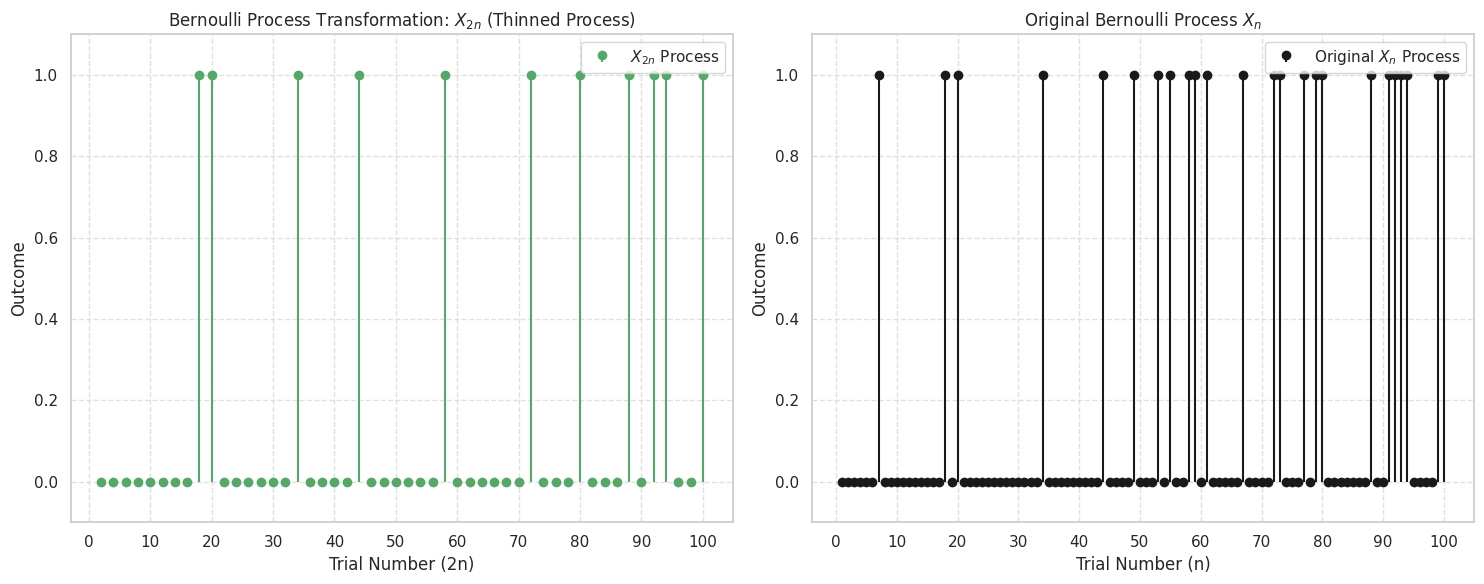

In [ ]:
''' Bernoulli Process Transformation: $X_{2n}$ (Thinned Process) '''

#### $X_{2n}$

This plot shows the $X_{2n}$ transformation, where we observe the original Bernoulli process only at even-numbered trials ($2, 4, 6, \dots$). As expected, this results in a sparser sequence of outcomes, but each observed trial still retains the original Bernoulli property with success probability $p$. Essentially, we've created a new Bernoulli process that runs at half the rate of the original one.

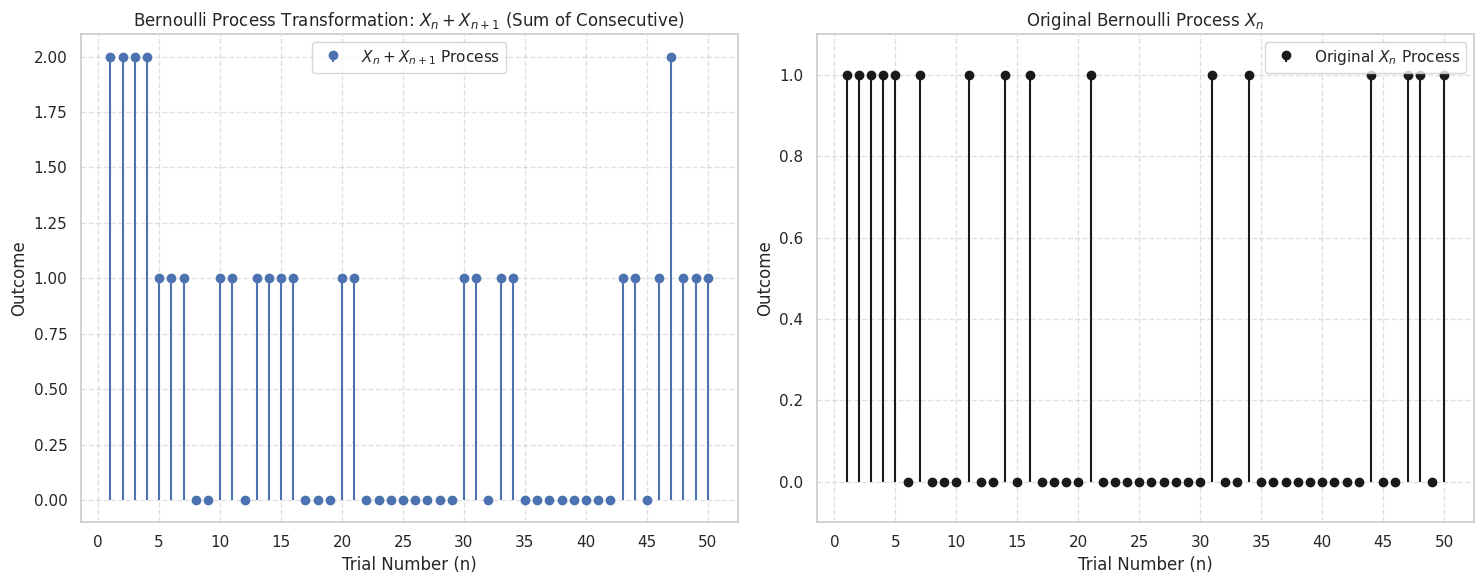

In [ ]:
''' Bernoulli Process Transformation: $X_n + X_{n+1}$ (Sum of Consecutive) '''

#### $X_n + X_{n+1}$

This plot shows the sum of consecutive Bernoulli trials, $X_n + X_{n+1}$. The possible outcomes are no longer just 0 or 1. Instead, they can be:
*   **0**: if both $X_n=0$ and $X_{n+1}=0$
*   **1**: if one of $X_n, X_{n+1}$ is 1 and the other is 0
*   **2**: if both $X_n=1$ and $X_{n+1}=1$

This transformation demonstrates a process that is no longer Bernoulli, as its outcomes are not binary. The dependencies introduced by summing overlapping trials are also apparent.

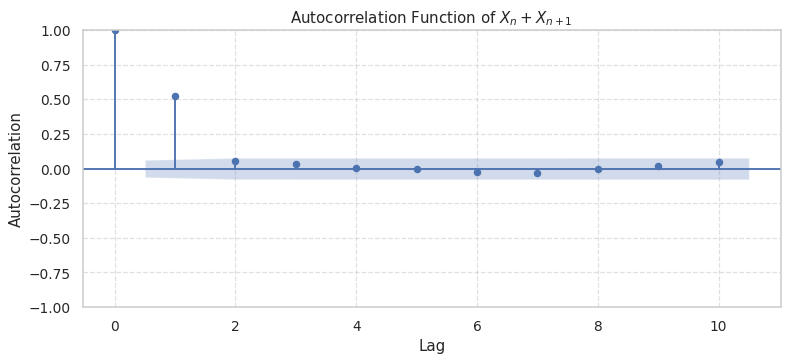

In [ ]:
''' Autocorrelation of $X_n + X_{n+1}$ Transformation '''

from statsmodels.graphics.tsaplots import plot_acf

#### Autocorrelation for $X_n + X_{n+1}$ Transformation

This plot displays the Autocorrelation Function (ACF) for the $X_n + X_{n+1}$ transformation. The ACF measures the correlation between a time series and a lagged version of itself.

*   Lag 0: The autocorrelation is always 1, as a series is perfectly correlated with itself.
*   Lag 1: Observe a significant positive autocorrelation at Lag 1. This is because $X_n + X_{n+1}$ at time $n$ shares the $X_{n+1}$ term with $X_{n+1} + X_{n+2}$ at time $n+1$. The common $X_{n+1}$ term creates a dependency, making the process correlated with its immediate past.
*   Lag 2 and beyond: The autocorrelation should quickly drop to near zero for lags 2 and higher. This indicates that the dependency primarily exists between adjacent terms. For example, $X_n + X_{n+1}$ is independent of $X_{n+2} + X_{n+3}$ because there are no overlapping terms.

This visualization clearly demonstrates the short-range dependency introduced by summing consecutive trials, contrasting with the independent nature of the original Bernoulli trials.

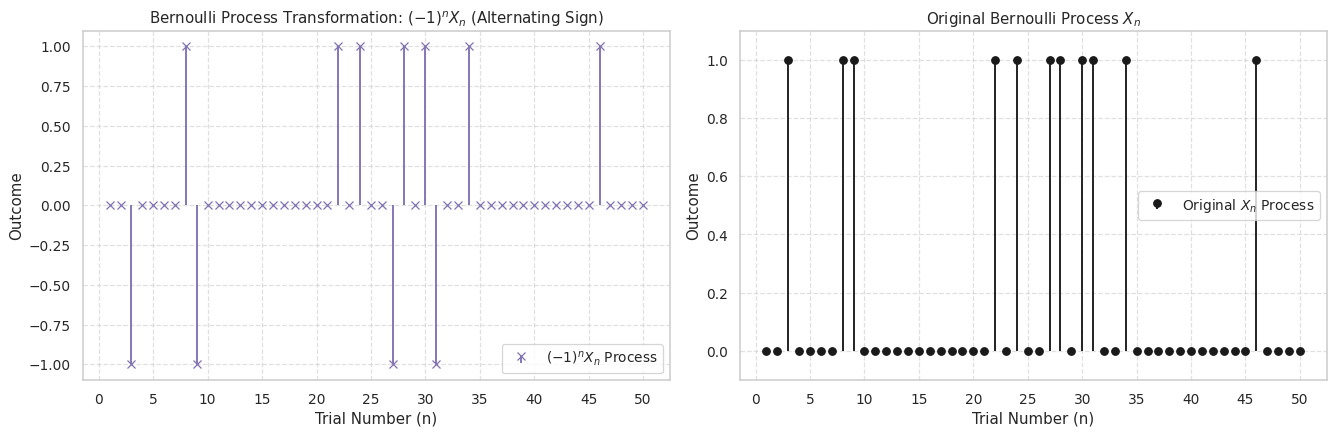

In [ ]:
''' Bernoulli Process Transformation: $(-1)^n X_n$ (Alternating Sign) '''

#### $(-1)^n X_n$

Here, if an original Bernoulli trial $X_n$ is a success (1), its value alternates between 1 (for even $n$) and -1 (for odd $n$). If $X_n$ is a failure (0), the outcome remains 0. The possible outcomes are now 0, 1, and -1. This process is clearly not Bernoulli, as it introduces negative values and modifies the nature of success/failure in an alternating pattern based on the trial number.

#### Poisson Approximation to Binomial Distribution

The Poisson distribution can be used to approximate the Binomial distribution when the number of trials ($n$) is large and the probability of success ($p$) is small, such that the product $\lambda = n \cdot p$ (the expected number of successes) remains constant.

Specifically, for a Binomial random variable $S \sim \text{Binomial}(n, p)$, as $n \to \infty$ and $p \to 0$ such that $np = \lambda$ (a fixed positive constant), the PMF of $S$ approaches the PMF of a Poisson random variable with parameter $\lambda$.

-   Binomial PMF: $P(S=k) = \binom{n}{k} p^k (1-p)^{n-k}$
-   Poisson PMF: $P(S=k) = \frac{\lambda^k e^{-\lambda}}{k!}$

For a fixed $k = 0, 1, 2, \dots$, we have $P(S=k)_{\text{Binomial}} \to P(S=k)_{\text{Poisson}}$. This approximation is particularly useful in modeling rare events that occur in a large number of trials.

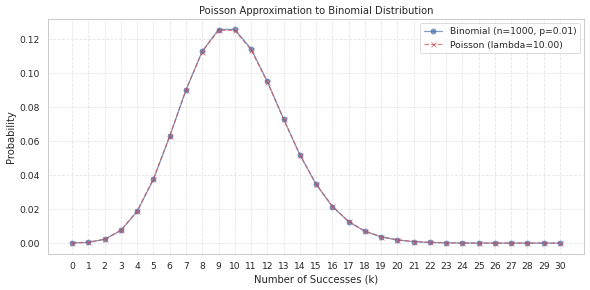

Binomial Mean: 10.00
Poisson Mean: 10.00
Binomial Variance: 9.90
Poisson Variance: 10.00


In [ ]:
from scipy.stats import binom, poisson

# Parameters for the Binomial distribution (large n, small p)
n_approx = 1000  # Large number of trials
p_approx = 0.01  # Small probability of success

# Calculate lambda for the Poisson approximation
lambda_approx = n_approx * p_approx
# Define a range of k values to plot (number of successes)
k_values = np.arange(0, int(3 * lambda_approx) + 1)
# Calculate PMF for Binomial distribution
binomial_pmf = binom.pmf(k_values, n_approx, p_approx)
# Calculate PMF for Poisson distribution
poisson_pmf = poisson.pmf(k_values, lambda_approx)

#### Poisson Approximation Visualization

The plot illustrates the concept of Poisson approximation to the Binomial distribution. We have two distributions plotted:

The **blue line** with circles represents the pmf of a **Binomial distribution** with $n = 1000$ and $p = 0.01$. The **red dashed line** with crosses represents the pmf of a **Poisson distribution** with $\lambda = n \cdot p = 1000 \cdot 0.01 = 10$.

As we observe, the shapes and probabilities of both distributions are very close to each other. This visual congruence demonstrates that when $n$ is large and $p$ is small (and $np$ is moderate), the Poisson distribution provides an excellent approximation for the Binomial distribution. This is a powerful result, allowing us to simplify calculations in many real-world scenarios, especially when dealing with rare events in a large population.

### Bernoulli Process Problems

This section presents a set of problems related to Bernoulli processes, focusing on common scenarios and their probabilistic analysis.

#### Problem 1: Number of Failures in a Fixed Number of Trials

Consider a sequence of $n$ independent Bernoulli trials, where the probability of 'failure' in a single trial is $p$. We are interested in the number of failures that occur within these $n$ trials.

**Derivation:**
Let $X$ be the random variable representing the number of failures in $n$ trials. If each trial has a probability of failure $p$ and a probability of success $(1-p)$, then $X$ follows a Binomial distribution. The PMF for $X=k$ failures is given by:

$P(X=k) = \binom{n}{k} p^k (1-p)^{n-k}$

where $\binom{n}{k} = \frac{n!}{k!(n-k)!}$ is the binomial coefficient, representing the number of ways to choose $k$ failures out of $n$ trials.

#### Problem 2: Expected Number of Quizzes up to the Third Failure

Suppose we are conducting quizzes, and the probability of failing any given quiz is $p$. We want to find the expected total number of quizzes taken until we observe the third failure.

**Derivation:**
This scenario is modeled by a Negative Binomial (or Pascal) distribution. Let $Y$ be the random variable representing the number of trials (quizzes) needed to achieve $r$ failures. If $p$ is the probability of failure on any trial, then $Y \sim NB(r, p)$.

The PMF for $Y=k$ trials (where $k \ge r$) is:
$P(Y=k) = \binom{k-1}{r-1} p^r (1-p)^{k-r}$

For the case of the third failure ($r=3$), the expected number of trials is:
$E[Y] = \frac{r}{p}$

In our specific problem, $r=3$, so the expected number of quizzes until the third failure is $E[Y] = \frac{3}{p}$.

In [ ]:
import numpy as np
from scipy.stats import nbinom

# Parameters
p_failure = 0.3  # Probability of failure in a single quiz
r_failures = 3   # Target number of failures

# Theoretical Expectation
theoretical_expected_trials = r_failures / p_failure

# Simulation
num_simulations = 10000

simulated_trials_until_failures = []
for _ in range(num_simulations):
    failures_count = 0
    trials_count = 0
    while failures_count < r_failures:
        trials_count += 1
        if np.random.rand() < p_failure:
            failures_count += 1
    simulated_trials_until_failures.append(trials_count)

empirical_expected_trials = np.mean(simulated_trials_until_failures)

Theoretical Expected Quizzes until 3 failures: 10.00
Empirical Expected Quizzes until 3 failures: 10.08


#### Problem 3: Conditional Probability of Failures

Consider a sequence of Bernoulli trials where the probability of failure is $p$. We are interested in two events: Event A with exactly one failure within the first 5 exams and Event B where the 6th exam is a failure. We want to calculate $P(A)$, $P(B)$, and the joint probability $P(A \cap B)$.

**Derivation:**
Let $p$ be the probability of failure and $(1-p)$ be the probability of success for any given exam. Probability of Event A, $P(A)$: This is a binomial probability for $n=5$ trials with $k=1$ failure, $P(A) = \binom{5}{1} p^1 (1-p)^{5-1} = 5p(1-p)^4$. Probability of Event B, $P(B)$: The 6th exam is an independent Bernoulli trial, so the probability of failure is simply, $P(B) = p$. Joint Probability $P(A \cap B)$: Since the trials are independent, Event A (outcomes of first 5 exams) and Event B (outcome of 6th exam) are independent.

Therefore, the joint probability is the product of their individual probabilities $P(A \cap B) = P(A) \cdot P(B) = \left(5p(1-p)^4\right) \cdot p = 5p^2(1-p)^4$.

In [ ]:
# Parameters
p_failure = 0.3 # Probability of failure for a single exam

# P(A): Exactly one failure in the first 5 exams
p_A_theoretical = 5 * p_failure * (1 - p_failure)**4
# P(B): The 6th exam is a failure
p_B_theoretical = p_failure
# P(A and B): P(A) * P(B) due to independence
p_A_and_B_theoretical = p_A_theoretical * p_B_theoretical

# Simulation
num_simulations = 100000
count_A, count_B, count_A_and_B = 0, 0, 0

for _ in range(num_simulations):
    # Simulate first 5 exams
    first_5_exams = np.random.rand(5) < p_failure
    num_failures_in_5 = np.sum(first_5_exams)

    # Check for Event A
    event_A_occurred = (num_failures_in_5 == 1)
    if event_A_occurred:
        count_A += 1

    # Simulate 6th exam
    sixth_exam_is_failure = (np.random.rand() < p_failure)

    # Check for Event B
    event_B_occurred = sixth_exam_is_failure
    if event_B_occurred:
        count_B += 1

    # Check for Event A and B
    if event_A_occurred and event_B_occurred:
        count_A_and_B += 1

empirical_p_A = count_A / num_simulations
empirical_p_B = count_B / num_simulations
empirical_p_A_and_B = count_A_and_B / num_simulations

Theoretical P(A) (1 failure in 5 exams): 0.3601
Theoretical P(B) (6th exam is a failure): 0.3000
Theoretical P(A and B): 0.1080

--- Simulation Results ---
Empirical P(A): 0.3595
Empirical P(B): 0.2999
Empirical P(A and B): 0.1080


#### Problem 4: Probability of "FF before SS"

Consider a sequence of Bernoulli trials (quizzes), where the probability of 'failure' is $p$ and 'success' is $(1-p)$. We are interested in the probability of **Event C**: observing two consecutive failures ('FF') before observing two consecutive successes ('SS').

**Derivation:**
Let $P_C$ be the probability of Event C. We can solve this using a system of equations by conditioning on the last observed trial. Let:
*   $P_0$: Probability of FF before SS, starting from no previous outcomes (initial state).
*   $P_F$: Probability of FF before SS, given the last outcome was a Failure.
*   $P_S$: Probability of FF before SS, given the last outcome was a Success.

From the initial state ($P_0$):
$P_0 = p \cdot P_F + (1-p) \cdot P_S$

From the state where the last outcome was a Failure ($P_F$):
If the next outcome is Failure (with probability $p$), we get 'FF', so we succeed (probability 1).
If the next outcome is Success (with probability $1-p$), we get 'FS'. The process continues as if the last outcome was a Success ($P_S$).
$P_F = p \cdot 1 + (1-p) \cdot P_S$

From the state where the last outcome was a Success ($P_S$):
If the next outcome is Failure (with probability $p$), we get 'SF'. The process continues as if the last outcome was a Failure ($P_F$).
If the next outcome is Success (with probability $1-p$), we get 'SS', so we fail (probability 0) to get 'FF' first.
$P_S = p \cdot P_F + (1-p) \cdot 0 = p \cdot P_F$

Now we solve the system of equations:
1.  $P_F = p + (1-p)P_S$
2.  $P_S = p P_F$

Substitute (2) into (1):
$P_F = p + (1-p)(p P_F)$
$P_F = p + p(1-p)P_F$
$P_F - p(1-p)P_F = p$
$P_F (1 - p(1-p)) = p$
$P_F (1 - p + p^2) = p$
$P_F = \frac{p}{1 - p + p^2}$

Now substitute $P_F$ back into (2) to find $P_S$:
$P_S = p \cdot \frac{p}{1 - p + p^2} = \frac{p^2}{1 - p + p^2}$

Finally, substitute $P_F$ and $P_S$ into the expression for $P_0$:
$P_0 = p \left( \frac{p}{1 - p + p^2} \right) + (1-p) \left( \frac{p^2}{1 - p + p^2} \right)$
$P_0 = \frac{p^2 + p^2(1-p)}{1 - p + p^2}$
$P_0 = \frac{p^2 (1 + 1 - p)}{1 - p + p^2}$
$P_0 = \frac{p^2 (2 - p)}{1 - p + p^2}$

**Expressing as a Geometric Series:**
The denominator $1 - p + p^2$ can be written as $1 - (p - p^2)$. This allows us to express the probability as a geometric series using the formula $\frac{1}{1-r} = \sum_{k=0}^{\infty} r^k$ for $|r| < 1$.

So, $P_C = \frac{p^2 (2 - p)}{1 - (p - p^2)} = p^2 (2 - p) \sum_{k=0}^{\infty} (p - p^2)^k$

This form represents the probability as an infinite sum where each term corresponds to the probability of the event occurring after a certain number of

In [ ]:
import numpy as np

def simulate_ff_before_ss(p_failure):
    """
    Simulates a sequence of Bernoulli trials until 'FF' or 'SS' occurs.
    Returns True if 'FF' occurs first, False if 'SS' occurs first.
    """
    last_outcome = None  # None: no previous outcome; 1: Failure; 0: Success
    while True:
        outcome = 1 if np.random.rand() < p_failure else 0
        if last_outcome is not None:
            if last_outcome == 1 and outcome == 1: # FF
                return True
            if last_outcome == 0 and outcome == 0: # SS
                return False
        last_outcome = outcome

p_failure_prob = 0.4  # Probability of failure for a single quiz
num_simulations = 100000

theoretical_pc = (p_failure_prob**2 * (2 - p_failure_prob)) / (1 - p_failure_prob + p_failure_prob**2)

ff_before_ss_count = 0
for _ in range(num_simulations):
    if simulate_ff_before_ss(p_failure_prob):
        ff_before_ss_count += 1

empirical_pc = ff_before_ss_count / num_simulations

Probability of Failure (p): 0.4
Theoretical P(FF before SS): 0.336842
Empirical P(FF before SS): 0.339300
Difference: 0.002458


#### Problem 5: Expected Number of Exams for Specific Success (Passing Unstudied)

Consider a student taking a series of exams. For each exam, let $p$ be the probability that the student studies, and $1-p$ be the probability that the student does not study.

If the student *has not studied* for an exam, there is a probability $q$ of passing, independently of any other exam or past outcomes. If the student *has studied*, we are not interested in the outcome for the purpose of this problem (i.e., it doesn't count towards our target event).

We want to find the expected total number of exams taken until the student has achieved 3 exams that are passed without having studied.

Derivation:
Let's define the event we are interested in as a 'target success': the student passes an exam *without having studied*.

First, we need to find the probability of this 'target success' occurring on any single exam. Let $P_{TS}$ denote this probability:
$P_{TS} = P(\text{Not Studied}) \times P(\text{Pass} \mid \text{Not Studied})$
$P_{TS} = (1-p) \times q$

Now, this problem can be reframed as waiting for a fixed number of 'successes' (3 'target successes') in a sequence of independent Bernoulli trials, where each trial's 'success' probability is $P_{TS}$. This scenario is modeled by a Negative Binomial distribution.

The expected number of trials (exams) needed to achieve $r$ successes in a Negative Binomial distribution with success probability $P_{TS}$ is given by:
$E[\text{Total Exams}] = \frac{r}{P_{TS}}$

In this problem, we are looking for $r=3$ target successes. Substituting $r=3$ and $P_{TS} = (1-p)q$:
$E[\text{Total Exams}] = \frac{3}{(1-p)q}$

Simple Graphical Tree for a Single Exam:
To illustrate the outcomes for a single exam and identify the 'target success':

```
Start
  |-- (p) --> Studied (Not a 'Target Success')
  |
  |-- (1-p) --> Not Studied
        |-- (q) --> Pass (This IS a 'Target Success')
        |
        |-- (1-q) --> Fail (Not a 'Target Success')
```

In [ ]:
import numpy as np

# Parameters
p_studies = 0.7  # Probability student studies (p)
q_pass_if_not_studied = 0.20  # Probability of passing if not studied (q)

# Number of target successes (exams passed without studying)
r_target_successes = 3

# Theoretical Calculation
# Probability of 'target success' on a single exam (passing without studying)
p_target_success = (1 - p_studies) * q_pass_if_not_studied

# Expected total number of exams using Negative Binomial expectation formula
theoretical_expected_exams = r_target_successes / p_target_success

# Simulation
num_simulations = 100000
simulated_exams_count = []

for _ in range(num_simulations):
    target_successes_achieved = 0
    exams_taken = 0
    while target_successes_achieved < r_target_successes:
        exams_taken += 1

        # Decide if student studies
        student_studies = np.random.rand() < p_studies

        if not student_studies: # Student did not study
            # Decide if student passes given they did not study
            passes = np.random.rand() < q_pass_if_not_studied
            if passes: # This is a 'target success'
                target_successes_achieved += 1
    simulated_exams_count.append(exams_taken)

empirical_expected_exams = np.mean(simulated_exams_count)

Probability student studies (p): 0.7
Probability of passing if not studied (q): 0.2
Probability of 'target success' (pass without studying): 0.0600
Theoretical Expected Total Exams until 3 passes without studying: 50.00

Empirical Expected Total Exams from simulation: 49.98
Difference (Theoretical - Empirical): 0.02


#### Interpretation of Problem 5 in terms of Bernoulli Process Splitting

Problem 5, "Expected Number of Exams for Specific Success (Passing Unstudied)", can be effectively interpreted using the concept of Bernoulli process splitting:

1.Initial Bernoulli Process (Exam Taken): Each exam taken can be considered a trial in an overarching Bernoulli process. The event in this process is simply an exam occurring.

2.First-Level Split (Study vs. Not Study): For each exam, a Bernoulli trial (with probability p_studies) determines if the student studies. This acts as the first split:
- Stream 1 (Student Studies): With probability p_studies, the outcome goes into this stream. For the problem's goal, these outcomes are disregarded.
- Stream 2 (Student Does Not Study): With probability (1 - p_studies), the outcome goes into this stream. This is the stream relevant to our 'target success'.

3.Second-Level Split/Filter (Pass vs. Fail, for 'Not Study' Stream): The 'Stream 2' (where the student did not study) undergoes a further Bernoulli split based on the probability q_pass_if_not_studied:
- Sub-Stream 2a (Passes, Not Studied): With probability q_pass_if_not_studied (conditional on not studying), the outcome is a pass. This is our target success event.
- Sub-Stream 2b (Fails, Not Studied): With probability (1 - q_pass_if_not_studied) (conditional on not studying), the outcome is a failure. These outcomes are not our target.

4.The Resulting Target Bernoulli Process: The event we are counting in Problem 5 (an exam passed *without studying*) effectively forms a new Bernoulli process. The probability of a 'success' in this new process is the product of the probabilities along the path that leads to it: P(target success) = P(Not Studied) * P(Pass | Not Studied) = (1 - p_studies) * q_pass_if_not_studied.

The problem then asks for the expected number of trials until we achieve 3 successes in this final, filtered Bernoulli process. This is why it follows a Negative Binomial distribution with the combined success probability, as derived and simulated in the notebook.

#### Problem 6: Distributing Items

Consider a scenario where an individual visits locations to distribute items. One item is given per visit if the call is answered and there is a person in residence.

$A = \{\text{call answered}\}$ with $P(A) = 3/4$, $B = \{\text{person in residence}\}$ with $P(B) = 1/3$

Events A and B are independent.

An item is distributed if both A and B occur. Therefore, the probability of distributing an item at any given stop is $P(\text{item given}) = P(A \cap B) = P(A) \cdot P(B) = (3/4) \cdot (1/3) = 1/4$

Let $p_{\text{item}} = 1/4$ be the probability of giving an item at a stop. Let $p_{\text{no_item}} = 1 - p_{\text{item}} = 3/4$ be the probability of not giving an item at a stop.

#### Pictorial View: Probability Tree for Item Distribution at a Single Stop

At each stop, there are four possible outcomes based on whether the call is answered (A) and if a person is in residence (B). These events are independent.

Let $P(A) = 3/4$, $P(B) = 1/3$. An item is distributed if and only if both A and B occur ($A \cap B$).

```
                              Start at a Stop
                                    |
                    +-------------------------------+--------------------------+
                    |                               |                          |
              Call Answered (A)               Call Not Answered (A^c)    |
                 P(A) = 3/4                       P(A^c) = 1/4             |
                    |                               |                          |
    +---------------+---------------+   +-----------+-------------+    +-----+
    |                               |   |                         |    |     |
Person in Res. (B)  No Person (B^c) Person in Res. (B) No Person (B^c)  No Person (B^c)
 P(B) = 1/3        P(B^c) = 2/3      P(B) = 1/3     P(B^c) = 2/3   
    |                   |               |               |         
    V                   V               V               V
Outcome 1: Item Given Outcome 2: No Item Outcome 3: No Item Outcome 4: No Item
(A and B)             (A and B^c)     (A^c and B)      (A^c and B^c)

Probability of each outcome:
1. P(Item Given) = P(A) * P(B) = (3/4) * (1/3) = 1/4  (This is p_item)
2. P(No Item)    = P(A) * P(B^c) = (3/4) * (2/3) = 2/4 = 1/2
3. P(No Item)    = P(A^c) * P(B) = (1/4) * (1/3) = 1/12
4. P(No Item)    = P(A^c) * P(B^c) = (1/4) * (2/3) = 2/12 = 1/6

Total probability of no item = 1/2 + 1/12 + 1/6 = 6/12 + 1/12 + 2/12 = 9/12 = 3/4 (This is p_no_item)
```

In [ ]:
import math

p_A = 3/4  # Probability of call answered
p_B = 1/3  # Probability of person in residence

p_item = p_A * p_B  # Probability of giving an item
p_no_item = 1 - p_item # Probability of not giving an item

Probability of giving an item (p_item): 0.2500
Probability of not giving an item (p_no_item): 0.7500


##### 1. Probability that no item is given by the end of the 2nd stop

Since each stop is an independent Bernoulli trial, the probability that no item is given by the end of the 2nd stop is the product of the probabilities of not giving an item at each stop.

$P(\text{no item by end of 2nd stop}) = P(\text{no item on stop 1}) \cdot P(\text{no item on stop 2}) = p_{\text{no_item}} \cdot p_{\text{no_item}} = p_{\text{no_item}}^2$

In [ ]:
# Part 1 Calculation
prob_part1 = p_no_item**2

Probability that no item is given by the end of the 2nd stop: 0.5625


##### 2. Probability that the first item is given on the 4th stop

This is a problem that can be solved using the Geometric distribution (number of trials until the first success). For the first item to be given on the 4th stop, it means no items were given on stops 1, 2, and 3, and an item was given on stop 4.

$P(\text{first item on 4th stop}) = P(\text{no item on 1}) \cdot P(\text{no item on 2}) \cdot P(\text{no item on 3}) \cdot P(\text{item on 4})$
$= p_{\text{no_item}}^3 \cdot p_{\text{item}}$

In [ ]:
# Part 2 Calculation
prob_part2 = (p_no_item**3) * p_item

Probability that the first item is given on the 4th stop: 0.1055


##### 3. If a second item is given on the 5th stop, what is the conditional probability that a third item will be given on the 8th stop?

Let $N_k$ be the stop number where the $k$-th item is given. We are given $N_2 = 5$, and we want to find $P(N_3 = 8 \mid N_2 = 5)$.

Since the events at each stop are independent, the condition $N_2 = 5$ means that 2 items have been given by stop 5. For the 3rd item to be given on stop 8, it implies that no item given at stop 6,   7 and 8.

Since the past history ($N_2=5$) doesn't affect future independent Bernoulli trials, we are simply looking for the probability of this sequence of events from stop 6 to 8.

$P(N_3 = 8 \mid N_2 = 5) = P(\text{no item on 6}) \cdot P(\text{no item on 7}) \cdot P(\text{item on 8})$
$= p_{\text{no_item}} \cdot p_{\text{no_item}} \cdot p_{\text{item}} = p_{\text{no_item}}^2 \cdot p_{\text{item}}$

In [ ]:
# Part 3 Calculation
prob_part3 = (p_no_item**2) * p_item

Conditional probability that a third item will be given on the 8th stop: 0.1406


##### 4. Probability that the second item is given on the fourth stop

For the second item to be given on the 4th stop, we need two conditions to be met:
1.  Exactly one item must have been given in the first three stops.
2.  An item must be given on the 4th stop.

The probability of condition 1 follows a Binomial distribution: $P(S_3=1) = \binom{3}{1} p_{\text{item}}^1 p_{\text{no_item}}^{3-1} = 3 \cdot p_{\text{item}} \cdot p_{\text{no_item}}^2$.

Then, we multiply by the probability of giving an item on the 4th stop:
$P(\text{second item on 4th stop}) = \binom{3}{1} p_{\text{item}}^1 p_{\text{no_item}}^2 \cdot p_{\text{item}}$
$= \binom{3}{1} p_{\text{item}}^2 p_{\text{no_item}}^2$

In [ ]:
# Part 4 Calculation
prob_part4 = math.comb(3, 1) * (p_item**2) * (p_no_item**2)

Probability that the second item is given on the fourth stop: 0.1055


##### 5. Given that the second item is not given on the third stop, the conditional probability that the second item is given by the fifth stop

Let $S_n$ be the number of items given by stop $n$. We want to find $P(S_5 \ge 2 \mid S_3 < 2)$. This is equivalent to $P(K_2 \le 5 \mid K_2 > 3)$, where $K_2$ is the stop number of the second item. Using the definition of conditional probability
$P(K_2 \le 5 \mid K_2 > 3) = \frac{P(K_2 \le 5 \text{ and } K_2 > 3)}{P(K_2 > 3)} = \frac{P(K_2 = 4) + P(K_2 = 5)}{P(K_2 > 3)}$

Numerator: $P(K_2 = 4) + P(K_2 = 5)$
*   $P(K_2 = 4)$: (1 item in first 3 stops, 1 item on 4th stop) $= \binom{3}{1} p_{\text{item}}^1 p_{\text{no_item}}^2 \cdot p_{\text{item}} = 3 \cdot p_{\text{item}}^2 \cdot p_{\text{no_item}}^2$
*   $P(K_2 = 5)$: (1 item in first 4 stops, 1 item on 5th stop) $= \binom{4}{1} p_{\text{item}}^1 p_{\text{no_item}}^3 \cdot p_{\text{item}} = 4 \cdot p_{\text{item}}^2 \cdot p_{\text{no_item}}^3$

Denominator: $P(K_2 > 3)$
This means that the second item is given on stop 4 or later. This occurs if $S_3 < 2$ (i.e., less than 2 items were given by stop 3). This can be $S_3 = 0$ or $S_3 = 1$.
*   $P(S_3 = 0)$: (0 items in first 3 stops) $= p_{\text{no_item}}^3$
*   $P(S_3 = 1)$: (1 item in first 3 stops) $= \binom{3}{1} p_{\text{item}}^1 p_{\text{no_item}}^2$
*   $P(K_2 > 3) = P(S_3 = 0) + P(S_3 = 1) = p_{\text{no_item}}^3 + 3 \cdot p_{\text{item}} \cdot p_{\text{no_item}}^2$

In [ ]:
# Part 5 Calculation

# Numerator: P(K_2 = 4) + P(K_2 = 5)
prob_k2_4 = math.comb(3, 1) * (p_item**2) * (p_no_item**2)
prob_k2_5 = math.comb(4, 1) * (p_item**2) * (p_no_item**3)
prob_numerator = prob_k2_4 + prob_k2_5

# Denominator: P(K_2 > 3) = P(S_3 = 0) + P(S_3 = 1)
prob_s3_0 = p_no_item**3
prob_s3_1 = math.comb(3, 1) * p_item * (p_no_item**2)
prob_denominator = prob_s3_0 + prob_s3_1

prob_part5 = prob_numerator / prob_denominator

P(K_2 = 4): 0.1055
P(K_2 = 5): 0.1055
P(K_2 > 3) (S_3 < 2): 0.8438
Conditional probability (Part 5): 0.2500


##### 6. Refill after the stop in which the last item is given. If starting with three items, probability that the five stops have been visited before the refill

We start with 3 items, and a refill occurs after the 3rd item is given. We want the probability that the 3rd item is given on or before the 5th stop. That is, $P(K_3 \le 5)$.

$P(K_3 \le 5) = P(K_3 = 3) + P(K_3 = 4) + P(K_3 = 5)$

*   $P(K_3 = 3)$: (2 items in first 2 stops, 1 item on 3rd stop) $= \binom{2}{2} p_{\text{item}}^2 p_{\text{no_item}}^0 \cdot p_{\text{item}} = p_{\text{item}}^3$
*   $P(K_3 = 4)$: (2 items in first 3 stops, 1 item on 4th stop) $= \binom{3}{2} p_{\text{item}}^2 p_{\text{no_item}}^1 \cdot p_{\text{item}} = 3 \cdot p_{\text{item}}^3 \cdot p_{\text{no_item}}$
*   $P(K_3 = 5)$: (2 items in first 4 stops, 1 item on 5th stop) $= \binom{4}{2} p_{\text{item}}^2 p_{\text{no_item}}^2 \cdot p_{\text{item}} = 6 \cdot p_{\text{item}}^3 \cdot p_{\text{no_item}}^2$

In [ ]:
# Part 6 Calculation

prob_k3_3 = (p_item**3)
prob_k3_4 = math.comb(3, 2) * (p_item**3) * p_no_item
prob_k3_5 = math.comb(4, 2) * (p_item**3) * (p_no_item**2)

prob_part6 = prob_k3_3 + prob_k3_4 + prob_k3_5

P(K_3 = 3): 0.0156
P(K_3 = 4): 0.0352
P(K_3 = 5): 0.0527
Probability that five stops have been visited before refill (Part 6): 0.1035


##### 7. If starting with exactly six items, the expected number of stops with resident in there without leaving any item (if the door was not answered) before she needs a refill

We start with 6 items, and a refill is needed after the 6th item is given. Let $N$ be the total number of stops until the 6th item is given. $N$ follows a Negative Binomial distribution with $r=6$ successes and success probability $p_{\text{item}}$.

The expected number of stops is $E[N] = r / p_{\text{item}} = 6 / (1/4) = 24$.

We are interested in a specific type of stop: 'resident in there without leaving any item (if the door was not answered)'. This means: The call was NOT answered (not A). A person WAS in residence (B). The events A and B are independent.

The probability of this specific event at any stop is $P(\text{not A} \cap B) = P(\text{not A}) \cdot P(B) = (1 - p_A) \cdot p_B = (1 - 3/4) \cdot (1/3) = (1/4) \cdot (1/3) = 1/12$. Let this be $p_{\text{cond_event}}$. Let $X_i$ be an indicator random variable that is 1 if this conditional event occurs at stop $i$, and 0 otherwise. We want to find the expected sum of these indicator variables over the $N$ stops, i.e., $E[\sum_{i=1}^{N} X_i]$.

By Wald's Identity, $E[\sum_{i=1}^{N} X_i] = E[N] \cdot E[X_i]$.
*   $E[N] = 24$, $E[X_i] = p_{\text{cond_event}} = 1/12$

The expected number of such stops is $24 \cdot (1/12) = 2$.

In [ ]:
# Part 7 Calculation

p_not_A = 1 - p_A
p_cond_event = p_not_A * p_B # P(not A and B)

expected_total_stops = 6 / p_item # E[N] for Negative Binomial(r=6, p=p_item)
expected_stops_with_cond_event = expected_total_stops * p_cond_event

Probability of 'resident there, door not answered': 0.0833
Expected total stops until refill: 24
Expected number of stops with resident in there without leaving any item (Part 7): 2.0000
